# Integrating Learning and Planning

- Model-Based Reinforcement Learning
- Integrated Architectures
- Simulation-Based Search

- Last lecture: learn **policy** directly from experience
- Previous lectures: learn **value function** directly from experience
- This lecture: learn **model** directly from experience 
- and use **planning** to construct a value function or policy
- Integrate learning and planning into a single architecture

## Model-based and model-free RL

Model-Free RL
- No model
- Learn value function (and/or policy) from experience

<img src="imgs/image-109.png" width="400px">

Model-Based RL
- Learn a model from experience
- Plan value function (and/or policy) from model

<img src="imgs/image-110.png" width="400px">

## Model based RL

<img src="imgs/image-111.png" width="500px">

**Advantages**:
- Can eﬃciently learn model by supervised learning methods
- Can reason about model uncertainty

**Disadvantages**:
- First learn a model, then construct a value function
    
    ⇒ **two sources of approximation error**

### What is a Model?

A **model** $\mathcal{M}$ is a representation of an MDP $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R} \rangle$, parametrized by $\eta$.

We assume state space $\mathcal{S}$ and action space $\mathcal{A}$ are known.

A model $\mathcal{M} = \langle \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$ approximates state transitions and rewards:

$$\mathcal{P}_\eta \approx \mathcal{P}, \quad \mathcal{R}_\eta \approx \mathcal{R}$$

$$S_{t+1} \sim \mathcal{P}_\eta(S_{t+1} \mid S_t, A_t)$$

$$R_{t+1} = \mathcal{R}_\eta(R_{t+1} \mid S_t, A_t)$$

We typically assume **conditional independence** between state transitions and rewards — knowing the current state and action is enough to predict each separately:

$$\mathbb{P}[S_{t+1}, R_{t+1} \mid S_t, A_t] = \mathbb{P}[S_{t+1} \mid S_t, A_t]\, \mathbb{P}[R_{t+1} \mid S_t, A_t]$$

**In plain terms:** instead of working with the true unknown environment, we learn a model $\mathcal{M}$ that approximates it. The model has two learned components: one that predicts *where you go* ($\mathcal{P}_\eta$) and one that predicts *what reward you get* ($\mathcal{R}_\eta$), and these two predictions are treated as independent of each other.

### Model Learning

**Goal:** estimate model $\mathcal{M}_\eta$ from experience $\{S_1, A_1, R_2, ..., S_T\}$.

This is a **supervised learning problem** — we treat each transition as a labeled training example:

$$S_1, A_1 \rightarrow R_2, S_2$$
$$S_2, A_2 \rightarrow R_3, S_3$$
$$\vdots$$
$$S_{T-1}, A_{T-1} \rightarrow R_T, S_T$$

Two sub-problems:

- Learning $s, a \rightarrow r$ is a **regression problem** — predict a scalar reward
- Learning $s, a \rightarrow s'$ is a **density estimation problem** — predict a distribution over next states

**Procedure:**
1. Pick a loss function (e.g. mean-squared error, KL divergence, ...)
2. Find parameters $\eta$ that minimise the empirical loss over collected transitions

**In plain terms:** we have a log of (state, action) → (reward, next state) tuples from real experience. We train a model on this data just like any supervised ML task — regression for rewards, density estimation for transitions — and tune $\eta$ to minimise prediction error.

### Examples of Models

- **Table Lookup Model** — stores the empirical average reward and transition counts for each $(s, a)$ pair in a table. Simple and exact, but only works for small, discrete state/action spaces.

- **Linear Expectation Model** — approximates transitions and rewards as a linear function of features of $(s, a)$. Fast and interpretable, but can only capture linear relationships.

- **Linear Gaussian Model** — assumes the next state $s'$ is Gaussian-distributed with a mean that is linear in $(s, a)$. Adds uncertainty estimates on top of the linear model; useful for continuous control.

- **Gaussian Process Model** — non-parametric Bayesian model that places a prior over functions. Automatically quantifies uncertainty and works well with little data, but scales poorly to high dimensions.

- **Deep Belief Network Model** — uses a deep neural network to model transitions and rewards. Can capture complex, non-linear dynamics; scales to high-dimensional inputs like images, but requires lots of data and compute.

- **...** — any supervised learning method can in principle be used as a model.

### Table Lookup Model

The model is an explicit MDP with estimated transitions $\hat{\mathcal{P}}$ and rewards $\hat{\mathcal{R}}$.

**Count visits** $N(s, a)$ to each state-action pair, then estimate by averaging:

$$\hat{\mathcal{P}}^a_{s,s'} = \frac{1}{N(s,a)} \sum_{t=1}^{T} \mathbf{1}(S_t, A_t, S_{t+1} = s, a, s')$$

$$\hat{\mathcal{R}}^a_s = \frac{1}{N(s,a)} \sum_{t=1}^{T} \mathbf{1}(S_t, A_t = s, a) R_t$$

**In plain terms:** $\hat{\mathcal{P}}$ is just the fraction of times action $a$ in state $s$ led to state $s'$. $\hat{\mathcal{R}}$ is just the average reward received when taking action $a$ in state $s$.

---

**Alternative — store raw tuples:**

- At each time-step $t$, record the experience tuple $\langle S_t, A_t, R_{t+1}, S_{t+1} \rangle$
- To sample from the model, randomly pick a stored tuple matching $\langle s, a, \cdot, \cdot \rangle$

**In plain terms:** instead of pre-computing averages, just keep a replay buffer of all past transitions and sample from it on demand. Equivalent in expectation, but lazier — no aggregation needed upfront.

<img src="imgs/image-112.png" width="500px"/>

### Planning with a Model

Given a learned model $\mathcal{M}_\eta = \langle \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$, solve the MDP $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$ using any standard planning algorithm:

- **Value iteration** — repeatedly update value estimates for all states until convergence
- **Policy iteration** — alternate between evaluating a policy and improving it greedily
- **Tree search** — simulate future trajectories by rolling out the model and pick the best action
- **...**

**In plain terms:** once you have a model, you forget about the real environment and just plan inside the model. The model acts as a cheap simulator — you can query it as many times as you want without any real-world cost, then use any planning method to extract a good policy.

### Sample-Based Planning

A simple but powerful approach: use the model **only to generate samples**, then apply model-free RL to those samples.

**Sample experience from the model:**

$$S_{t+1} \sim \mathcal{P}_\eta(S_{t+1} \mid S_t, A_t)$$

$$R_{t+1} = \mathcal{R}_\eta(R_{t+1} \mid S_t, A_t)$$

**Then apply any model-free RL algorithm to the simulated data:**

- Monte-Carlo control
- Sarsa
- Q-learning

Sample-based planning methods are often **more efficient** than full planning.

**In plain terms:** instead of solving the full MDP analytically, just use the model as a simulator to cheaply generate fake experience, then run standard RL on that fake data as if it were real. The key insight is that you never need to solve the model explicitly — you just sample from it. This is efficient because you sidestep the cost of sweeping over the entire state space.

#### back to AB example
<img src="imgs/image-113.png" width="500px"/>

### Planning with an Inaccurate Model

Given an imperfect model $\langle \mathcal{P}_\eta, \mathcal{R}_\eta \rangle \neq \langle \mathcal{P}, \mathcal{R} \rangle$:

- Performance of model-based RL is **limited to the optimal policy for the approximate MDP** $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}_\eta, \mathcal{R}_\eta \rangle$
- Model-based RL is only as good as the estimated model — garbage in, garbage out
- An inaccurate model leads to a **suboptimal policy**

**Two solutions:**

- **Solution 1:** when the model is too wrong, fall back to **model-free RL** directly on real experience
- **Solution 2:** **reason explicitly about model uncertainty** — track how confident you are in the model and act cautiously in regions where it is unreliable

**In plain terms:** if your simulator is wrong, planning inside it will find a policy that is optimal in the fake world but potentially terrible in the real one. You either abandon the model when it fails, or build uncertainty awareness into the planning process so the agent knows when not to trust its own model.

In [17]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---------------------------------------------------------------------------
# Learn P_η and R_η for FrozenLake (slippery) via Table Lookup Model
# ---------------------------------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=True)
n_states = env.observation_space.n  # 16
n_actions = env.action_space.n  # 4

# Counters
N_sa = np.zeros((n_states, n_actions))  # visit counts N(s,a)
N_sas = np.zeros((n_states, n_actions, n_states))  # transition counts N(s,a,s')
R_sum = np.zeros((n_states, n_actions))  # cumulative reward sum for (s,a)

# Learned model tables
P_hat = np.zeros((n_states, n_actions, n_states))  # P_η(s'|s,a)
R_hat = np.zeros((n_states, n_actions))  # R_η(s,a)

# Track model error over episodes for convergence plot
P_errors = []  # KL or L1 distance to true P
R_errors = []  # MSE to true R

# --- Build true P and R from env for comparison ---
# Env that inherit from gymnasium.envs.toy_text store their dynamics in env.unwrapped.P as a dict of lists:
P_true = np.zeros((n_states, n_actions, n_states))
R_true = np.zeros((n_states, n_actions))
for s in range(n_states):
    for a in range(n_actions):
        for prob, ns, rew, done in env.unwrapped.P[s][a]:
            P_true[s, a, ns] += prob
            R_true[s, a] += prob * rew


In [18]:
# --- Collect experience with random exploration ---
n_episodes = 3000

for ep in range(n_episodes):
    state, _ = env.reset()

    while True:
        action = env.action_space.sample()  # uniform random policy
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Update counts
        N_sa[state, action] += 1
        N_sas[state, action, next_state] += 1
        R_sum[state, action] += reward

        # Update model estimates
        n = N_sa[state, action]
        P_hat[state, action] = N_sas[state, action] / n
        R_hat[state, action] = R_sum[state, action] / n

        state = next_state
        if done:
            break

    # Compute model error every 50 episodes
    if (ep + 1) % 50 == 0:
        # L1 error on P (only for visited (s,a) pairs)
        visited = N_sa > 0
        p_err = 0.0
        count = 0
        for s in range(n_states):
            for a in range(n_actions):
                if visited[s, a]:
                    p_err += np.sum(np.abs(P_hat[s, a] - P_true[s, a]))
                    count += 1
        p_err /= max(count, 1)
        P_errors.append(p_err)

        # MSE on R (only for visited pairs)
        r_err = np.mean((R_hat[visited] - R_true[visited]) ** 2)
        R_errors.append(r_err)

print(f"Total transitions collected: {int(N_sa.sum())}")
print(f"Visited (s,a) pairs: {int((N_sa > 0).sum())} / {n_states * n_actions}")
print(f"Final P error (L1): {P_errors[-1]:.4f}")
print(f"Final R error (MSE): {R_errors[-1]:.6f}")

Total transitions collected: 22742
Visited (s,a) pairs: 44 / 64
Final P error (L1): 0.0777
Final R error (MSE): 0.000084


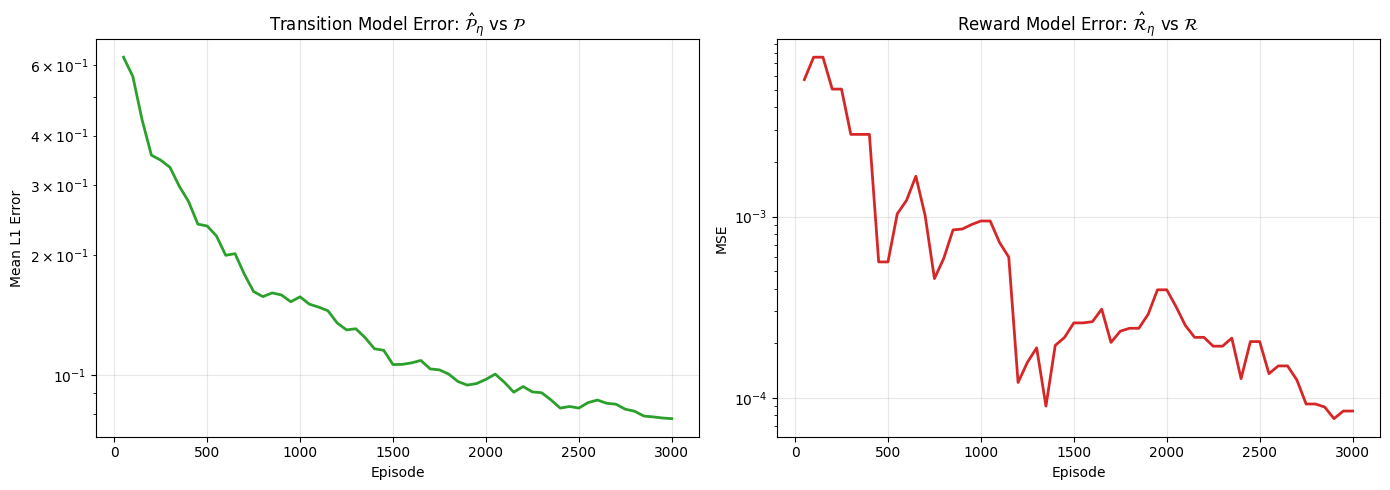

In [19]:
# ---------------------------------------------------------------------------
# Visualize model convergence: P_η → P and R_η → R
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
episodes_x = np.arange(50, n_episodes + 1, 50)

# --- Left: P error convergence ---
ax = axes[0]
ax.plot(episodes_x, P_errors, color="#2ca02c", linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("Mean L1 Error")
ax.set_title(r"Transition Model Error: $\hat{\mathcal{P}}_\eta$ vs $\mathcal{P}$")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

# --- Right: R error convergence ---
ax = axes[1]
ax.plot(episodes_x, R_errors, color="#d62728", linewidth=2)
ax.set_xlabel("Episode")
ax.set_ylabel("MSE")
ax.set_title(r"Reward Model Error: $\hat{\mathcal{R}}_\eta$ vs $\mathcal{R}$")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

plt.tight_layout()
plt.show()

Inspecting state 6 (row=1, col=2, cell='F')



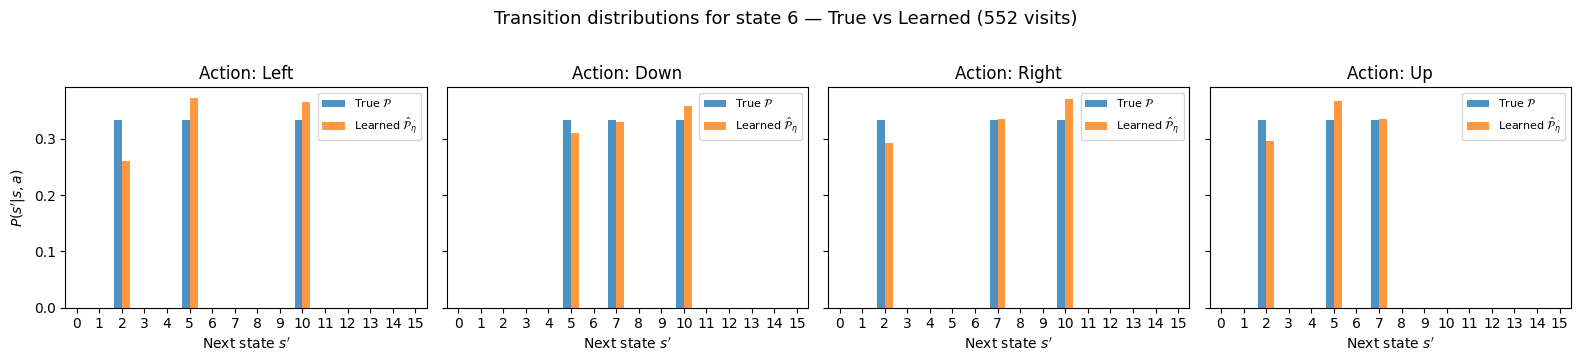

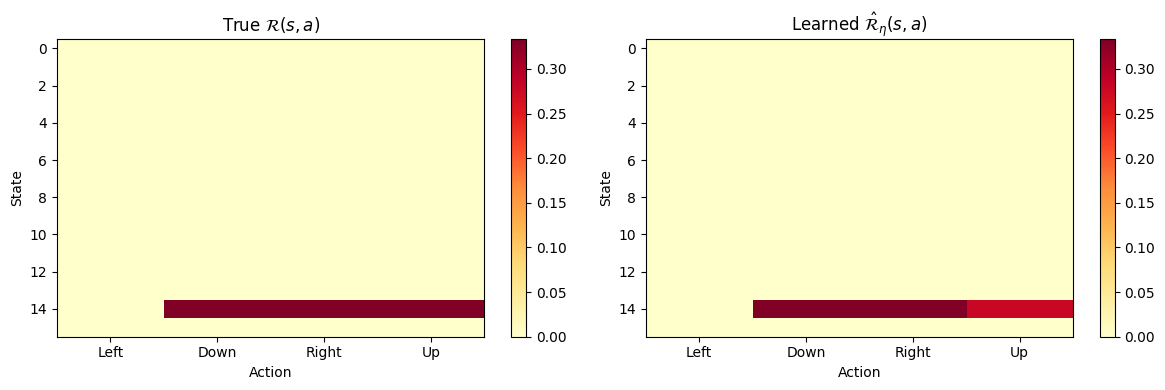


--- Sample-based planning: generating experience from learned model ---
Sampling 5 trajectories from P_η, R_η:

  Traj 1: 0 → 0 → 0 → 4 → 8 → 4 → 0 → 0 → 0 → 1 → 2 → 1 → 1 → 5  |  R=0.00  |  end=H
  Traj 2: 0 → 4 → 4 → 5  |  R=0.00  |  end=H
  Traj 3: 0 → 0 → 0 → 4 → 5  |  R=0.00  |  end=H
  Traj 4: 0 → 4 → 0 → 0 → 0 → 1 → 0 → 0 → 0 → 0 → 4 → 5  |  R=0.00  |  end=H
  Traj 5: 0 → 0 → 1 → 0 → 1 → 5  |  R=0.00  |  end=H


In [20]:
# ---------------------------------------------------------------------------
# Inspect learned model: compare P_η vs P_true for a specific state
# ---------------------------------------------------------------------------
grid_size = 4
desc = env.unwrapped.desc.astype(str)
action_names = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}

# Pick an interesting state to inspect (state 6 = row 1, col 2 — surrounded by holes)
inspect_state = 6
row, col = divmod(inspect_state, grid_size)
print(
    f"Inspecting state {inspect_state} (row={row}, col={col}, cell='{desc[row, col]}')\n"
)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for a in range(n_actions):
    ax = axes[a]
    x = np.arange(n_states)
    width = 0.35

    bars_true = ax.bar(
        x - width / 2,
        P_true[inspect_state, a],
        width,
        label="True $\\mathcal{P}$",
        color="#1f77b4",
        alpha=0.8,
    )
    bars_hat = ax.bar(
        x + width / 2,
        P_hat[inspect_state, a],
        width,
        label="Learned $\\hat{\\mathcal{P}}_\\eta$",
        color="#ff7f0e",
        alpha=0.8,
    )

    ax.set_title(f"Action: {action_names[a]}")
    ax.set_xlabel("Next state $s'$")
    if a == 0:
        ax.set_ylabel("$P(s' | s, a)$")
    ax.set_xticks(x)
    ax.set_xlim(-0.5, n_states - 0.5)
    # Only show ticks for states with nonzero probability
    ax.legend(fontsize=8)

fig.suptitle(
    f"Transition distributions for state {inspect_state} — True vs Learned ({int(N_sa[inspect_state].sum())} visits)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

# --- Reward comparison heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, (title, R_mat) in enumerate(
    [
        ("True $\\mathcal{R}(s, a)$", R_true),
        ("Learned $\\hat{\\mathcal{R}}_\\eta(s, a)$", R_hat),
    ]
):
    ax = axes[idx]
    im = ax.imshow(R_mat, cmap="YlOrRd", aspect="auto", vmin=0, vmax=R_true.max())
    ax.set_xlabel("Action")
    ax.set_ylabel("State")
    ax.set_xticks(range(n_actions))
    ax.set_xticklabels([action_names[a] for a in range(n_actions)])
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# --- Sample-based planning: generate fake experience from learned model ---
print("\n--- Sample-based planning: generating experience from learned model ---")
print("Sampling 5 trajectories from P_η, R_η:\n")

for traj in range(5):
    state = 0  # start state
    path = [state]
    total_r = 0
    for step in range(20):
        action = np.random.randint(n_actions)
        # Sample next state from learned P_η
        next_state = np.random.choice(n_states, p=P_hat[state, action])
        # Get reward from learned R_η
        reward = R_hat[state, action]
        total_r += reward
        path.append(next_state)
        # Check if terminal (hole or goal)
        r, c = divmod(next_state, grid_size)
        if desc[r, c] in ("H", "G"):
            break
        state = next_state
    outcome = desc[divmod(path[-1], grid_size)[0], divmod(path[-1], grid_size)[1]]
    print(
        f"  Traj {traj + 1}: {' → '.join(map(str, path))}  |  R={total_r:.2f}  |  end={outcome}"
    )

##  Integrated Architectures
### Dyna

#### Real and Simulated Experience

We consider two sources of experience:

---

##### Real Experience — Sampled from the environment (true MDP)

$$S' \sim \mathcal{P}^a_{s,s'}$$
$$R = \mathcal{R}^a_s$$

The next state $S'$ and reward $R$ come from the **actual environment**. This is ground truth — whatever the real world (or simulator acting as ground truth) returns when you take action $a$ in state $s$.

---

##### Simulated Experience — Sampled from a learned model (approximate MDP)

$$S' \sim \mathcal{P}_\eta(S' \mid S, A)$$
$$R = \mathcal{R}_\eta(R \mid S, A)$$

Here $\eta$ (eta) parameterizes a **learned model** of the environment. Instead of interacting with the real world, you query this model to generate synthetic transitions. The model approximates the true dynamics and reward function.

---

**Why two sources?**

Real experience is accurate but costly (limited interactions with the environment). Simulated experience is cheap — once you have a model, you can generate as many transitions as you want. Model-based RL methods combine both: use real experience to **learn the model**, then use simulated experience to **plan or train the policy** more sample-efficiently.

#### Integrating Learning and Planning


##### Model-Free RL
- **No model** — never tries to learn how the environment works
- **Learn** value function (and/or policy) directly from real experience
  - e.g. Q-learning, TD, Monte Carlo — just observe $(s, a, r, s')$ tuples and update

---

##### Model-Based RL (using Sample-Based Planning)
- **Learn a model** from real experience — fit $\mathcal{P}_\eta$ and $\mathcal{R}_\eta$ to observed transitions
- **Plan** value function (and/or policy) from simulated experience
  - Use the learned model to generate synthetic rollouts, then run RL on those

---

##### Dyna
- Learn a model from real experience
- **Learn and plan** value function (and/or policy) from **both** real and simulated experience

----

**The key distinction:**

| | Source of value/policy updates |
|---|---|
| Model-Free | Real experience only |
| Model-Based | Real experience → model → simulated experience → value/policy |

**Dyna** is the hybrid: it does both simultaneously. 

- Real transitions update the value function **directly** (like model-free)
- Real transitions also improve the **model**
- The model then generates simulated transitions that **also** update the value function (like model-based planning)

So each real interaction does double duty — it trains the value function *and* refines the model, which in turn produces extra training signal. This is why Dyna can be much more sample-efficient than pure model-free RL.|

Model-based RL trades **model learning complexity** for **sample efficiency** — you need fewer real interactions because you can "imagine" additional ones.

<img src="imgs/image-114.png" width="500px">

#### <a id="dyna-q-algorithm"></a>Dyna-Q Algorithm

**Initialize** $Q(s, a)$ and $Model(s, a)$ for all $s \in \mathcal{S}$, $a \in \mathcal{A}(s)$

**Do forever:**

**(a)** $S \leftarrow$ current (nonterminal) state

**(b)** $A \leftarrow \varepsilon\text{-greedy}(S, Q)$
— pick a (mostly greedy) action using current Q-values

**(c)** Execute $A$; observe reward $R$ and next state $S'$
— one real interaction with the environment

**(d)** $Q(S, A) \leftarrow Q(S, A) + \alpha\bigl[R + \gamma \max_a Q(S', a) - Q(S, A)\bigr]$
— standard Q-learning update on the **real** transition

**(e)** $Model(S, A) \leftarrow R, S'$
— store the observed transition in the model (assumes deterministic: same $(s,a)$ always gives same $(r, s')$)

**(f)** Repeat $n$ times — sample $n$ **simulated** transitions from the model and apply Q-learning to each:
$$S \leftarrow \text{random previously observed state}$$
$$A \leftarrow \text{random action previously taken in } S$$
$$R, S' \leftarrow Model(S, A)$$
$$Q(S, A) \leftarrow Q(S, A) + \alpha\bigl[R + \gamma \max_a Q(S', a) - Q(S, A)\bigr]$$


---

**The structure in one real step:**

| Step | What happens |
|---|---|
| (a–c) | Interact with real environment |
| (d) | Learn from real transition |
| (e) | Update model with real transition |
| (f) ×n | Plan: learn from $n$ simulated transitions |

The $n$ planning steps are cheap (no real interaction needed), so increasing $n$ improves sample efficiency at the cost of compute. With $n=0$ you get plain Q-learning; with large $n$ you approach full model-based planning.

### Dyna-Q on FrozenLake


In [21]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [22]:
def greedy_action(Q, state):
    """Break ties uniformly across actions with the same value."""
    best_value = np.max(Q[state])
    best_actions = np.flatnonzero(np.isclose(Q[state], best_value))
    return int(np.random.choice(best_actions))


def epsilon_greedy(Q, state, n_actions, epsilon):
    """Select action using epsilon-greedy policy with random tie-breaking."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return greedy_action(Q, state)


In [23]:
def dyna_q(env, n_episodes=1000, n_planning=10, alpha=0.1, gamma=0.99, epsilon=0.1):
    """
    Dyna-Q: Q-learning + table-lookup model learning + planning.


    For each real step:
      1. Q-learning update (direct RL)
      2. Update model with observed (s, a) -> (r, s')
      3. n_planning simulated Q-learning updates from model (planning)
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    # Table-lookup model: model[(s, a)] = (reward, next_state)
    model = {}
    # Track visited (state, action) pairs for sampling during planning
    visited_sa = []

    episode_rewards = []
    episode_steps = []

    for _ in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        steps = 0

        while True:
            action = epsilon_greedy(Q, state, n_actions, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # --- Direct RL: Q-learning update ---
            Q[state, action] += alpha * (
                reward
                + gamma * np.max(Q[next_state]) * (1 - terminated)
                - Q[state, action]
            )

            # --- Model learning: store transition ---
            if (state, action) not in model:
                visited_sa.append((state, action))
            model[(state, action)] = (reward, next_state, terminated)

            # --- Planning: n simulated Q-learning updates ---
            for _ in range(n_planning):
                idx = np.random.randint(len(visited_sa))
                s_sim, a_sim = visited_sa[idx]
                r_sim, s_next_sim, term_sim = model[(s_sim, a_sim)]
                Q[s_sim, a_sim] += alpha * (
                    r_sim
                    + gamma * np.max(Q[s_next_sim]) * (1 - term_sim)
                    - Q[s_sim, a_sim]
                )

            state = next_state
            total_reward += reward
            steps += 1
            if done:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(steps)

    return Q, episode_rewards, episode_steps, model

#### Training

Using **FrozenLake-v1** (non-slippery) — a 4×4 grid where the agent must reach the goal while avoiding holes. Deterministic transitions make the learned model accurate immediately.

In [24]:
n_episodes = 300
n_runs = 20  # average over multiple runs to reduce variance

env = gym.make("FrozenLake-v1", is_slippery=False)

configs = [
    ("Dyna-Q (n=5)", 5),
    ("Dyna-Q (n=10)", 10),
    ("Dyna-Q (n=50)", 50),
]

results = {}
for label, n_plan in configs:
    all_rewards = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        _, rewards, _, _ = dyna_q(env, n_episodes=n_episodes, n_planning=n_plan)
        all_rewards[run] = rewards
    results[label] = all_rewards
    # cumulative success rate at end
    final_success = all_rewards[:, -50:].mean()
    print(f"{label:20s} | final success rate (last 50 eps): {final_success:.2f}")

Dyna-Q (n=5)         | final success rate (last 50 eps): 0.88
Dyna-Q (n=10)        | final success rate (last 50 eps): 0.86
Dyna-Q (n=50)        | final success rate (last 50 eps): 0.90


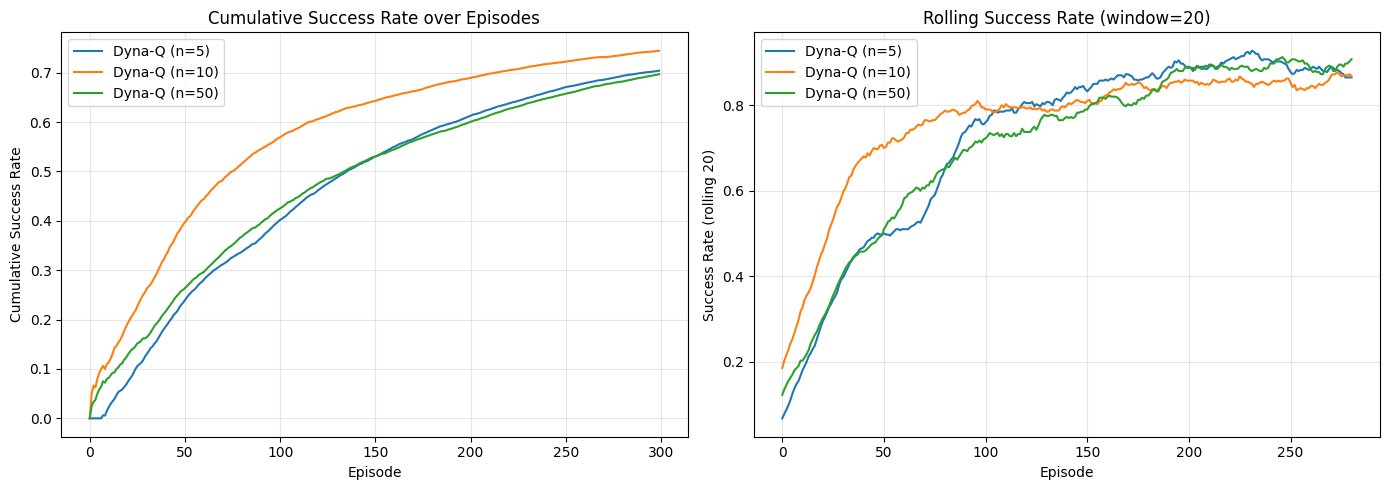

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

window = 20  # rolling window for smoothing
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# --- Left: cumulative success rate ---
ax = axes[0]
for (label, _), color in zip(configs, colors):
    mean_rewards = results[label].mean(axis=0)
    cum_success = np.cumsum(mean_rewards) / (np.arange(n_episodes) + 1)
    ax.plot(cum_success, label=label, color=color)
ax.set_xlabel("Episode")
ax.set_ylabel("Cumulative Success Rate")
ax.set_title("Cumulative Success Rate over Episodes")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: rolling success rate ---
ax = axes[1]
for (label, _), color in zip(configs, colors):
    mean_rewards = results[label].mean(axis=0)
    rolling = np.convolve(mean_rewards, np.ones(window) / window, mode="valid")
    ax.plot(rolling, label=label, color=color)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Success Rate (rolling {window})")
ax.set_title(f"Rolling Success Rate (window={window})")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Inspecting the Learned Model and Policy

The table-lookup model stores $(s, a) \to (r, s', \text{terminated})$ for every transition the agent has observed. Let's train a single Dyna-Q agent and visualize:
- The **learned policy** (greedy w.r.t. Q)
- The **learned model** (what transitions the agent remembers)

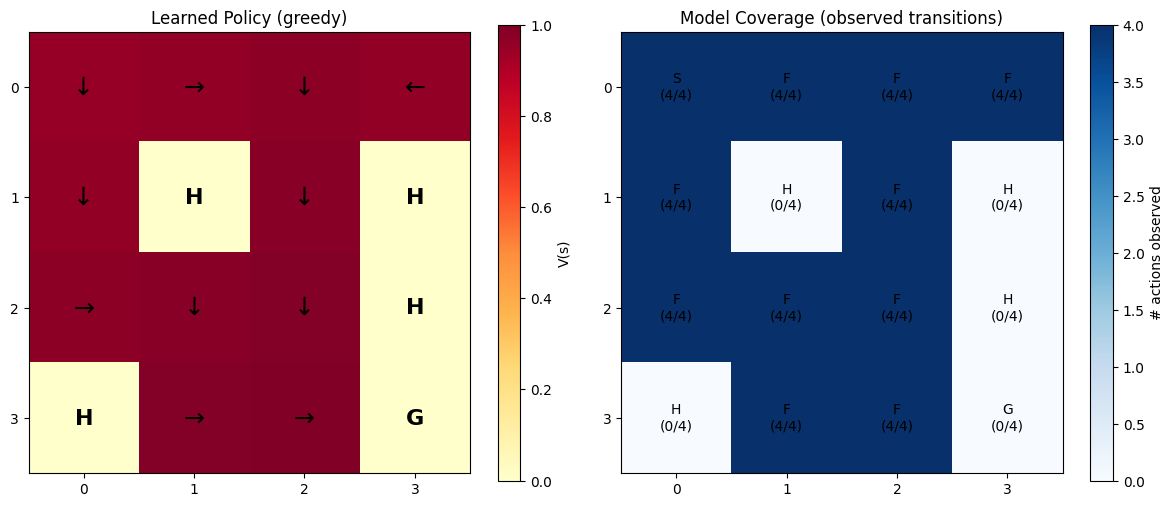


Sample model entries:
  Model(0, ←) → s'=0, r=0, done=False
  Model(0, ↓) → s'=4, r=0, done=False
  Model(0, →) → s'=1, r=0, done=False
  Model(0, ↑) → s'=0, r=0, done=False
  Model(1, ←) → s'=0, r=0, done=False
  Model(1, ↓) → s'=5, r=0, done=True
  Model(1, →) → s'=2, r=0, done=False
  Model(1, ↑) → s'=1, r=0, done=False
  Model(2, ←) → s'=1, r=0, done=False
  Model(2, ↓) → s'=6, r=0, done=False


In [26]:
# Train a single Dyna-Q agent
env_vis = gym.make("FrozenLake-v1", is_slippery=False)
Q_dyna, _, _, learned_model = dyna_q(env_vis, n_episodes=1000, n_planning=50)

# FrozenLake 4x4 layout
grid_size = 4
action_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
desc = env_vis.unwrapped.desc.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Learned policy ---
ax = axes[0]
V = np.max(Q_dyna, axis=1).reshape(grid_size, grid_size)
im = ax.imshow(V, cmap="YlOrRd", interpolation="nearest")
plt.colorbar(im, ax=ax, label="V(s)")

for s in range(grid_size * grid_size):
    r, c = divmod(s, grid_size)
    cell = desc[r, c]
    if cell in ("H", "G"):
        ax.text(c, r, cell, ha="center", va="center", fontsize=16, fontweight="bold")
    else:
        best_a = greedy_action(Q_dyna, s)
        ax.text(c, r, action_arrows[best_a], ha="center", va="center", fontsize=18)

ax.set_title("Learned Policy (greedy)")
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))

# --- Right: Learned model coverage ---
ax = axes[1]
coverage = np.zeros((grid_size, grid_size))
for s, a in learned_model:
    r, c = divmod(s, grid_size)
    coverage[r, c] += 1  # count how many actions have been observed

im2 = ax.imshow(coverage, cmap="Blues", interpolation="nearest")
plt.colorbar(im2, ax=ax, label="# actions observed")

for s in range(grid_size * grid_size):
    r, c = divmod(s, grid_size)
    cell = desc[r, c]
    n_observed = sum(1 for a in range(4) if (s, a) in learned_model)
    ax.text(c, r, f"{cell}\n({n_observed}/4)", ha="center", va="center", fontsize=10)

ax.set_title("Model Coverage (observed transitions)")
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))

plt.tight_layout()
plt.show()

print("\nSample model entries:")
for (s, a), (rew, ns, term) in sorted(learned_model.items())[:10]:
    print(f"  Model({s}, {action_arrows[a]}) → s'={ns}, r={rew}, done={term}")

### Watch the Agent Play

Run the trained Dyna-Q policy greedily on FrozenLake and animate the agent's path step by step.

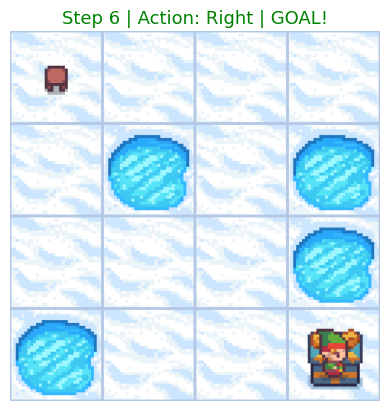

: 

In [ ]:
from IPython.display import clear_output
import time

action_names = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}


def play_episode(Q, env_id="FrozenLake-v1", is_slippery=False, delay=0.5):
    """Play one episode using greedy policy from Q, rendering RGB frames."""
    env = gym.make(env_id, is_slippery=is_slippery, render_mode="rgb_array")
    state, _ = env.reset()

    clear_output(wait=True)
    plt.imshow(env.render())
    plt.axis("off")
    plt.title("Step 0 | Start", fontsize=13)
    plt.show()
    time.sleep(delay)

    for step in range(1, 51):
        action = greedy_action(Q, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        clear_output(wait=True)
        plt.imshow(env.render())
        plt.axis("off")
        status = (
            "GOAL!" if (terminated and reward > 0) else ("HOLE!" if terminated else "")
        )
        plt.title(
            f"Step {step} | Action: {action_names[action]} | {status}",
            fontsize=13,
            color="green"
            if status == "GOAL!"
            else ("red" if status == "HOLE!" else "black"),
        )
        plt.show()
        time.sleep(delay)

        if done:
            break
        state = next_state

    env.close()


play_episode(Q_dyna)

## Simulation-Based Search

## Forward Search

- **Forward search** algorithms select the best action by **lookahead**
- They build a **search tree** with the current state $s_t$ at the root
- Use a **model** of the MDP to simulate what happens next

<img src="imgs/image-115.png" width=500px><div/>

- **No need to solve the whole MDP** — only the sub-MDP starting from the current state $s_t$

---

**How it works:**

Starting from $s_t$, the algorithm:
1. Simulates sequences of actions and resulting states using the model
2. Evaluates the outcomes at the leaves (terminal states or depth cutoff)
3. Backs up values through the tree to pick the best action at the root

**Key insight:** you only build the tree forward from *now* — you ignore all states you'll never reach from $s_t$. This makes it tractable even when the full state space is huge.

The deeper the tree, the better the decision — but the more compute it costs.

## Simulation-Based Search

- **Forward search** paradigm using **sample-based planning**
- **Simulate** episodes of experience from $s_t$ (now) using the model
- Apply **model-free RL** to the simulated episodes

<img src="imgs/image-116.png" width=500px/><div/>

---

**How it works:**

Instead of exhaustively expanding the full tree, you:
1. Start from current state $s_t$
2. **Sample** rollouts (full or partial episodes) through the tree using the model
3. Run model-free RL (e.g. MC, TD, Q-learning) on those simulated episodes to estimate values

---

**Why this is powerful:**

| Exhaustive forward search | Simulation-based search |
|---|---|
| Expands all branches | Samples promising paths |
| Exponential cost in depth | Scales much better |
| Exact but intractable | Approximate but practical |

You get the benefit of lookahead planning **without** needing to enumerate every possible future. The model generates experience; model-free RL extracts value from it. This is the core idea behind algorithms like **Monte Carlo Tree Search (MCTS)**.

#### Simulation-Based Search (detail)

**Simulate** episodes of experience from $s_t$ (now) using the model:

$$\{s_t^k, A_t^k, R_{t+1}^k, \ldots, S_T^k\}_{k=1}^K \sim \mathcal{M}_\nu$$

— generate $K$ simulated episodes, all starting from the current state $s_t$, using model $\mathcal{M}_\nu$

---

**Apply model-free RL to the simulated episodes:**

| Model-free algorithm | Applied to simulated episodes |
|---|---|
| Monte-Carlo control | → **Monte-Carlo search** |
| Sarsa (TD) | → **TD search** |

---

**The pattern is simple:**

Any model-free RL algorithm can be "lifted" into a planning algorithm by feeding it simulated episodes instead of real ones.

- **Monte-Carlo search**: run episodes to termination, use returns $G_t$ to update $Q(s,a)$
- **TD search**: bootstrap after each step using $Q$ estimates — no need to wait for episode end, works for continuing tasks too

### Simple Monte-Carlo Search

Given a model $\mathcal{M}_\nu$ and a **simulation policy** $\pi$:

**For each action $a \in \mathcal{A}$**:

- Simulate $K$ episodes starting from the current (real) state $s_t$:

$$\{s_t, a, R^k_{t+1}, S^k_{t+1}, A^k_{t+1}, \ldots, S^k_T\}_{k=1}^K \sim \mathcal{M}_\nu, \pi$$

> You use the model $\mathcal{M}_\nu$ to generate $K$ imaginary rollouts. Each rollout starts by taking action $a$ from the real state $s_t$, then follows the simulation policy $\pi$ until the end of the episode.

- Evaluate each action by its **mean return** (Monte-Carlo evaluation):

$$Q(s_t, a) = \frac{1}{K} \sum_{k=1}^{K} G_t \xrightarrow{P} q_\pi(s_t, a)$$

> Average the total return $G_t$ across the $K$ simulated episodes. By the law of large numbers, this converges to the true action-value $q_\pi(s_t, a)$ as $K \to \infty$.

Select the current (real) action with the **maximum estimated value**:

$$a_t = \underset{a \in \mathcal{A}}{\operatorname{argmax}}\; Q(s_t, a)$$

> Pick whichever action had the highest average simulated return. Only this action is actually executed in the real environment — the rest of the simulation is discarded.

---

**Key idea:** Instead of learning $Q$ over many training steps, you estimate it on-the-fly by simulating many futures from the current state using the model. This is planning at decision time, not offline learning.

#### Monte-Carlo Tree Search (Evaluation)

Given a model $\mathcal{M}_\nu$:

Simulate $K$ episodes from the current (real) state $s_t$ using simulation policy $\pi$:

$$\{s_t, A^k_t, R^k_{t+1}, S^k_{t+1}, \ldots, S^k_T\}_{k=1}^K \sim \mathcal{M}_\nu, \pi$$

> Same as Simple MC Search, but now we keep track of **all visited (state, action) pairs** across all rollouts — not just the root action.

**Build a search tree** containing all visited states and actions.

> As rollouts accumulate, a tree grows: the root is $s_t$, branches are actions taken, nodes are states reached. Many rollouts share early branches, so the tree reuses experience efficiently.

**Evaluate** $Q(s, a)$ by the **mean return** of all episodes that passed through $(s, a)$:

$$Q(s, a) = \frac{1}{N(s,a)} \sum_{k=1}^{K} \sum_{u=t}^{T} \mathbf{1}(S_u, A_u = s, a)\, G_u \xrightarrow{P} q_\pi(s, a)$$

- $N(s, a)$: number of times $(s, a)$ was visited across all rollouts
- $\mathbf{1}(S_u, A_u = s, a)$: indicator — 1 if step $u$ of rollout $k$ visited $(s, a)$, else 0
- $G_u$: total return from that step onward

> For every (state, action) pair in the tree, average the returns of all rollouts that went through it. This is just standard MC evaluation, applied at every node — not just the root.

After search is finished, select the real action with the **maximum value at the root**:

$$a_t = \underset{a \in \mathcal{A}}{\operatorname{argmax}}\; Q(s_t, a)$$

---

**Difference from Simple MC Search:**
Simple MC Search only estimates $Q$ at the root ($s_t$). MCTS builds estimates for the **entire tree** of reachable states, so deeper nodes also get evaluated — enabling smarter simulation policies (e.g. UCB tree policy) that focus rollouts on promising branches.

#### Monte-Carlo Tree Search (Simulation)

In MCTS, the simulation policy $\pi$ **improves over time** — unlike Simple MC Search where $\pi$ is fixed.

Each simulation has **two phases**:

- **Tree policy/in-tree** (improves): inside the tree, pick actions to maximise $Q(S, A)$
  > Within the already-explored part of the tree, act greedily (or near-greedily) w.r.t. current $Q$ estimates. This focuses rollouts on promising branches.

- **Default policy/out-of-tree** (fixed): outside the tree, pick actions randomly
  > Once a rollout reaches an unexplored node (a leaf), continue with a simple random policy until the episode ends. This provides a return signal for the new node.

**Repeat each simulation:**

1. **Evaluate** $Q(S, A)$ by Monte-Carlo evaluation (average returns as before)
2. **Improve** the tree policy, e.g. by $\varepsilon-greedy$(Q)$

> After each batch of rollouts, update $Q$ estimates and make the tree policy more greedy. Over time, the tree policy gets better and better at directing simulations toward high-value paths.

This is **Monte-Carlo control applied to simulated experience** — the same GPI loop (evaluate → improve → evaluate → ...) from standard RL, but running entirely inside the model.

Converges to the **optimal search tree**:

$$Q(S, A) \to q_*(S, A)$$

---

**The key insight:** The two-phase design lets MCTS balance exploration and exploitation naturally. The default policy ensures every new node gets some return estimate; the improving tree policy progressively concentrates computation on the best parts of the search space.

### Game of GO

- The ancient oriental game of Go is 2500 years old
- Considered to be the hardest classic board game
- Traditional game-tree search has failed in Go

#### Rules of Go

- Usually played on a 19×19 board, but also 13×13 or 9×9 for shorter games
- The rules are simple, but the strategy is extremely deep
- Black and white take turns placing stones on the board intersections
- A stone (or group of stones) is captured and removed when it is completely surrounded by the opponent's stones
- The player who controls the most territory (empty intersections) at the end wins

> **Territory** = empty areas of the board surrounded and controlled by your stones.

> **Capture** = surround all of an opponent group's "liberties" (adjacent empty points) to remove it from the board.

<img src="imgs/image-117.png" width=500px/><div/>


<img src="imgs/go_capture_example.svg" width=500px>

The dashed circle on the left marks the last liberty — an empty intersection adjacent to the black group. 

Once white plays there (the stone with the red outline on the right), the group has zero liberties and is removed from the board. 

The ✕ marks show where black's stones were.

Key rule: a stone or connected group survives as long as it has at least one liberty. Fill the last one → capture.

#### Position Evaluation in Go

- How good is a position $s$?
- Reward function (undiscounted):

$$R_t = 0 \quad \text{for all non-terminal steps } t < T$$

$$R_T = \begin{cases} 1 & \text{if Black wins} \\ 0 & \text{if White wins} \end{cases}$$

> No reward is given during the game — only +1 at the end if Black wins, 0 if White wins.

- Policy $\pi = \langle \pi_B, \pi_W \rangle$ selects moves for both players

> A policy is just a strategy: given a board position, which move to play. Here we model both players having a policy.

- Value function (how good is position $s$):

$$v_\pi(s) = \mathbb{E}_\pi [R_T \mid S = s] = \mathbb{P}[\text{Black wins} \mid S = s]$$

$$v_*(s) = \max_{\pi_B} \min_{\pi_W} v_\pi(s)$$

> $v_\pi(s)$ is the probability Black wins from position $s$, if both players follow policy $\pi$.
>
> $v_*(s)$ is the **optimal value**: Black tries to **maximise** the win probability, White tries to **minimise** it. This is a minimax problem — both players play perfectly against each other.

#### Monte-Carlo evaluation in Go

<img src="imgs/image-118.png" width=500px>


The idea: instead of solving $v_*(s)$ exactly (which is intractable for Go),
**estimate** it by playing out many random games from position $s$ and averaging the results.

#### Algorithm

1. Start from the current position $s$
2. Play out $N$ full games to the end using a **random (or fast) policy** for both players
3. Record each outcome: 1 if Black wins, 0 if White wins
4. Average the outcomes:

$$V(s) = \frac{1}{N} \sum_{i=1}^{N} R_T^{(i)}$$

#### Example from the diagram

4 simulations are run from position $s$:

| Simulation | Outcome |
|---|---|
| 1 | 1 (Black wins) |
| 2 | 1 (Black wins) |
| 3 | 0 (White wins) |
| 4 | 0 (White wins) |

$$V(s) = \frac{2}{4} = 0.5$$

→ Black has a 50% estimated win probability from this position.

#### Why it works

- The more simulations you run, the closer $V(s)$ converges to the true $v_*(s)$
- No hand-crafted evaluation function needed — the outcome signal does all the work
- The quality of the estimate depends heavily on the **simulation policy**:
  a smarter rollout policy → better estimates with fewer simulations






#### Monte-Carlo Tree Search (MCTS)

MCTS builds a search tree incrementally. Each node stores **wins/visits**.
Two policies work together:

- **Tree policy** — navigate and expand the *known* tree (UCB-guided)
- **Default policy** — play out the rest of the game randomly (rollout)

The result of each rollout is **backed up** through the tree.

---

##### Iteration-by-iteration walkthrough

###### Iteration 1

<img src="imgs/image-119.png" width=500px>

- Tree has only the root (current state). No children yet.
- Tree policy: stay at root (nothing to choose from)
- Default policy: run a random rollout → outcome **1** (Black wins)
- Root updated: **1/1** (1 win, 1 visit)

###### Iteration 2

<img src="imgs/image-120.png" width=500px>

- Root is **1/1**. One child is now expanded.
- Tree policy: move into that child (the star node)
- Default policy: rollout from there → outcome **0**
- Child updated: 0/1. Root backed up: **1/2**

###### Iteration 3

<img src="imgs/image-121.png" width=500px>

- Root is **2/3**... wait — a second child (circle node, 0/1) is now visible.
- Tree policy: the root selects the *other* unvisited child (UCB favours unexplored nodes)
- Default policy: rollout → outcome **1**
- That child: 0/1. Root backed up: **2/3**

###### Iteration 4

<img src="imgs/image-122.png" width=500px>

- Root: **0/4**. Two children: left (1/2), right (0/1).
- Tree policy: descend into the left child (better win rate), then expand *its* child (the star)
- The star node starts at 0/1
- Default policy: rollout → outcome **0**
- Backed up: star 0/1, left child stays 1/2, root **0/4**

###### Iteration 5

<img src="imgs/image-123.png" width=500px>

- Root: **3/5**. Left child: **2/3**, right child: **0/1**
- Tree policy: descend into left child again (higher UCB), land on the star node (now 1/1)
- Default policy: rollout → outcome **1**
- Backed up: star **1/1**, left child **2/3**, root **3/5**

---

#### UCB — Upper Confidence Bound

UCB stands for **Upper Confidence Bound**.

The name comes directly from the formula: instead of just using a node's
current average, you compute an *optimistic upper bound* on how good it might be.

$$\text{UCB} = \underbrace{\frac{w_i}{n_i}}_{\text{exploitation}} + c \underbrace{\sqrt{\frac{\ln N}{n_i}}}_{\text{exploration}}$$

- $w_i$ — wins at node $i$
- $n_i$ — visits at node $i$
- $N$ — total visits at the parent
- $c$ — constant balancing the two terms

##### The two terms

**Exploitation** ($w_i / n_i$): the current win rate — prefer nodes that have
done well so far.

**Exploration** ($\sqrt{\ln N / n_i}$): a confidence bonus — large when $n_i$
is small (rarely visited), shrinks as visits increase.

**$c$** — constant balancing the two



#### Key idea: UCB tree policy

At each node, choose the child that maximises:

$$\text{UCB} = \frac{w_i}{n_i} + c \sqrt{\frac{\ln N}{n_i}}$$

This ensures the tree grows in promising directions while still exploring alternatives.

##### Intuition

A node visited only once has a huge confidence bonus, so UCB stays high even if it lost — we don't have enough data to rule it out yet.
As you visit it more, the bonus shrinks and the win rate dominates.

> Always pick the node you *can't yet rule out* as being the best.

> Once you've explored it enough to be confident it's bad,

> its UCB drops and you stop wasting visits on it.


---

#### Summary

| Step | What happens |
|---|---|
| **Select** | Walk tree using UCB until a leaf |
| **Expand** | Add one new child node |
| **Simulate** | Run random rollout to terminal state |
| **Backpropagate** | Update wins/visits up to the root |

After many iterations, pick the child of the root with the **highest visit count** as the best move.

### MCTS on Taxi-v3

Apply Monte-Carlo Tree Search to the **Taxi-v3** environment from Gymnasium.

**Taxi-v3** is a discrete MDP with 500 states (5×5 grid × 5 passenger locations × 4 destinations) and 6 actions (south, north, east, west, pickup, dropoff). The agent must pick up a passenger and drop them off at the correct destination.

Since Taxi-v3 has known dynamics (accessible via `env.unwrapped.P`), we use the environment's transition model directly as our simulator — no model learning needed. This lets us focus purely on the **MCTS planning** algorithm.

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import math
import time
from IPython.display import clear_output

In [3]:
class MCTSNode:
    """
    A node in the MCTS search tree.

    Each node stores:
    - state: the environment state at this node
    - parent: reference to parent node (None for root)
    - parent_action: the action taken from parent to reach this node
    - children: dict mapping action -> child MCTSNode
    - visits (N): number of times this node has been visited
    - value (W): total accumulated reward through this node
    - untried_actions: actions not yet expanded from this node
    """

    def __init__(self, state, parent=None, parent_action=None, n_actions=6):
        self.state = state
        self.parent = parent
        self.parent_action = parent_action
        self.children = {}
        self.visits = 0
        self.value = 0.0
        self.untried_actions = list(range(n_actions))

    @property
    def is_fully_expanded(self):
        return len(self.untried_actions) == 0

    @property
    def is_leaf(self):
        return len(self.children) == 0

    def ucb_score(self, c=1.41):
        """UCB1 score: exploitation (average value) + exploration bonus."""
        if self.visits == 0:
            return float("inf")
        exploitation = self.value / self.visits
        exploration = c * math.sqrt(math.log(self.parent.visits) / self.visits)
        return exploitation + exploration

    def best_child(self, c=1.41):
        """Select child with highest UCB score."""
        return max(self.children.values(), key=lambda child: child.ucb_score(c))

    def best_action(self):
        """After search: pick action leading to child with most visits."""
        return max(self.children.values(), key=lambda child: child.visits).parent_action

In [4]:
def simulate_step(env_P, state, action):
    """
    Simulate one step using the environment's known transition model.

    env_P[state][action] returns a list of (probability, next_state, reward, done).
    We sample one transition according to the probabilities.
    """
    transitions = env_P[state][action]
    probs = [t[0] for t in transitions]
    idx = np.random.choice(len(transitions), p=probs)
    _, next_state, reward, done = transitions[idx]
    return next_state, reward, done


def mcts_search(
    state, env_P, n_actions, n_iterations=100, max_rollout_depth=50, c=1.41, gamma=0.99
):
    """
    Run MCTS from a given state and return the best action.

    Follows the 4-step MCTS loop:
    1. SELECT   — walk tree using UCB until a leaf or unexpanded node
    2. EXPAND   — add one new child node
    3. SIMULATE — random rollout from the new node (default policy)
    4. BACKPROPAGATE — update wins/visits up to the root

    Parameters
    ----------
    state : int
        Current environment state (root of the search tree).
    env_P : dict
        Environment transition model env.unwrapped.P.
    n_actions : int
        Number of actions in the environment.
    n_iterations : int
        Number of MCTS iterations (rollouts).
    max_rollout_depth : int
        Maximum depth for the random rollout (default policy).
    c : float
        UCB exploration constant.
    gamma : float
        Discount factor for returns.
    """
    root = MCTSNode(state, n_actions=n_actions)

    for _ in range(n_iterations):
        node = root
        sim_state = state

        # --- 1. SELECT: traverse tree using UCB ---
        while node.is_fully_expanded and not node.is_leaf:
            node = node.best_child(c)
            sim_state = node.state

        # --- 2. EXPAND: add one unexplored child ---
        if not node.is_fully_expanded:
            action = node.untried_actions.pop()
            next_state, reward, done = simulate_step(env_P, sim_state, action)
            child = MCTSNode(
                next_state, parent=node, parent_action=action, n_actions=n_actions
            )
            node.children[action] = child
            node = child
            sim_state = next_state
        else:
            reward = 0
            done = False

        # --- 3. SIMULATE: random rollout (default policy) ---
        rollout_return = reward
        discount = gamma
        rollout_state = sim_state

        if not done:
            for _ in range(max_rollout_depth):
                rollout_action = np.random.randint(n_actions)
                rollout_state, r, d = simulate_step(
                    env_P, rollout_state, rollout_action
                )
                rollout_return += discount * r
                discount *= gamma
                if d:
                    break

        # --- 4. BACKPROPAGATE: update value/visits up to root ---
        while node is not None:
            node.visits += 1
            node.value += rollout_return
            node = node.parent

    return root.best_action(), root

#### Taxi-v3 Environment Setup

The **Taxi-v3** environment:
- **500 states**: 5×5 grid (25 positions) × 5 passenger locations (4 fixed + in-taxi) × 4 destinations
- **6 actions**: south (0), north (1), east (2), west (3), pickup (4), dropoff (5)
- **Rewards**: +20 for successful dropoff, −1 per step, −10 for illegal pickup/dropoff
- **Deterministic transitions**: each (state, action) leads to exactly one next state

Since transitions are deterministic and the model is known via `env.unwrapped.P`, MCTS can plan optimally with enough iterations.

In [5]:
env = gym.make("Taxi-v3")
n_states = env.observation_space.n  # 500
n_actions = env.action_space.n  # 6
env_P = env.unwrapped.P  # known transition model

print(f"States: {n_states}, Actions: {n_actions}")
print(f"Action mapping: 0=south, 1=north, 2=east, 3=west, 4=pickup, 5=dropoff")

# Show a sample transition
sample_state = 328
sample_action = 4  # pickup
print(
    f"\nSample transition: P[{sample_state}][{sample_action}] = {env_P[sample_state][sample_action]}"
)
print("Format: (probability, next_state, reward, done)")

States: 500, Actions: 6
Action mapping: 0=south, 1=north, 2=east, 3=west, 4=pickup, 5=dropoff

Sample transition: P[328][4] = [(1.0, 328, -10, False)]
Format: (probability, next_state, reward, done)


#### Running MCTS on Taxi-v3

At each step, we run a fresh MCTS search from the current state, pick the best action, and step the real environment. We evaluate how MCTS performs with different numbers of iterations (the "thinking budget").

In [ ]:
def run_mcts_episode(
    env, env_P, n_actions, n_iterations=100, max_steps=200, gamma=0.99
):
    """
    Play one full episode using MCTS for action selection at each step.

    At every step:
    1. Run MCTS from the current state (fresh tree each time)
    2. Pick the best action (most visited child of root)
    3. Step the real environment
    """
    state, _ = env.reset()
    total_reward = 0
    steps = 0
    trajectory = [state]

    for _ in range(max_steps):
        action, _ = mcts_search(
            state,
            env_P,
            n_actions,
            n_iterations=n_iterations,
            gamma=gamma,
        )
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        total_reward += reward
        steps += 1
        trajectory.append((action, next_state, reward))

        if done:
            break
        state = next_state

    return total_reward, steps, trajectory


# --- Evaluate MCTS with different iteration budgets ---
configs = [
    ("MCTS (20 iters)", 20),
    ("MCTS (50 iters)", 50),
    ("MCTS (100 iters)", 100),
]

n_eval_episodes = 50
results = {}

for label, n_iter in configs:
    rewards = []
    steps_list = []
    for ep in range(n_eval_episodes):
        r, s, _ = run_mcts_episode(env, env_P, n_actions, n_iterations=n_iter)
        rewards.append(r)
        steps_list.append(s)
    results[label] = {"rewards": rewards, "steps": steps_list}
    mean_r = np.mean(rewards)
    mean_s = np.mean(steps_list)
    success_rate = np.mean([r > 0 for r in rewards])
    print(
        f"{label:20s} | mean reward: {mean_r:7.1f} | mean steps: {mean_s:5.1f} | success rate: {success_rate:.2f}"
    )

MCTS (500 iters)     | mean reward:  -366.7 | mean steps: 136.7 | success rate: 0.00


/var/folders/p4/b3p9tbn949714k6ymvrnpslm0000gq/T/ipykernel_33489/498173487.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)
/var/folders/p4/b3p9tbn949714k6ymvrnpslm0000gq/T/ipykernel_33489/498173487.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


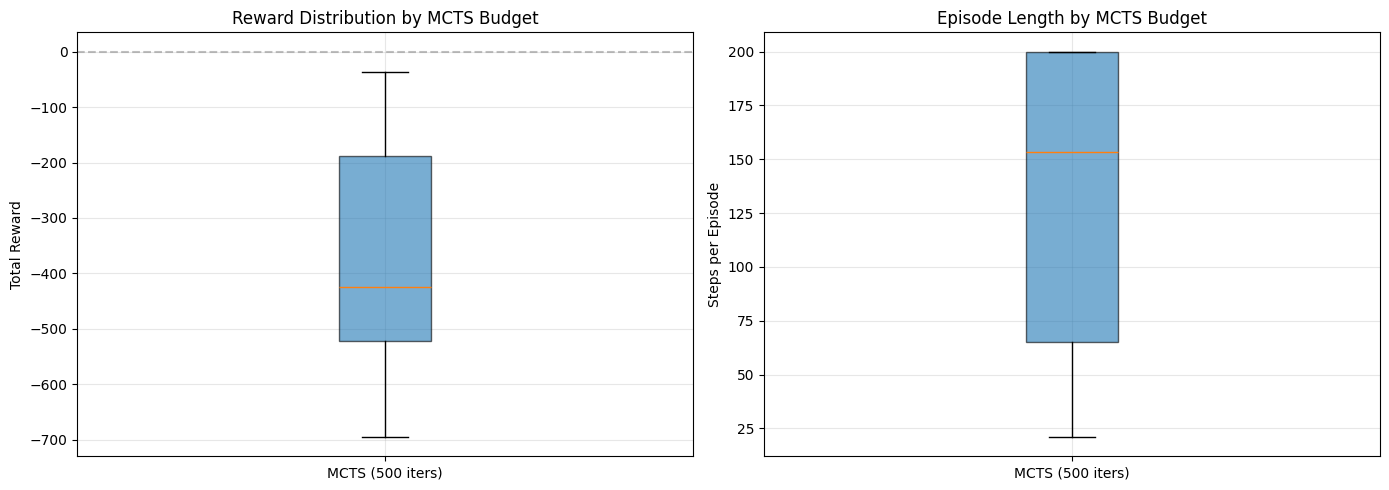

In [12]:
# --- Visualize results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# --- Left: reward distribution ---
ax = axes[0]
data = [results[label]["rewards"] for label, _ in configs]
labels = [label for label, _ in configs]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Total Reward")
ax.set_title("Reward Distribution by MCTS Budget")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

# --- Right: steps distribution ---
ax = axes[1]
data = [results[label]["steps"] for label, _ in configs]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("Steps per Episode")
ax.set_title("Episode Length by MCTS Budget")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Inspecting the MCTS Search Tree

Let's run MCTS from a single state and inspect the root node — how many times each action was visited and what value was estimated. This shows how MCTS concentrates search on promising actions.

State 243: taxi=(2,2), passenger=at R, dest=B
Root visits: 500
Best action: North

Action       Visits  Avg Value        UCB
------------------------------------------
South             3    -172.86    -170.83
North           488    -161.48    -161.32 <-- best
East              1    -184.91    -181.40
West              1    -172.04    -168.52
Pickup            2    -168.00    -165.52
Dropoff           5    -168.46    -166.88


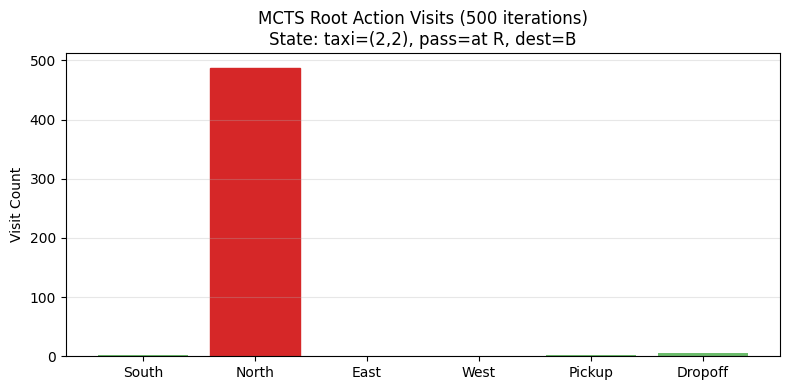

In [13]:
action_names = {0: "South", 1: "North", 2: "East", 3: "West", 4: "Pickup", 5: "Dropoff"}

# Run MCTS from a fresh state
state, _ = env.reset()
best_action, root = mcts_search(state, env_P, n_actions, n_iterations=500)

# Decode state for display
taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(state)
locs = [(0, 0), (0, 4), (4, 0), (4, 3)]
loc_names = ["R", "G", "Y", "B"]
pass_desc = f"in taxi" if pass_loc == 4 else f"at {loc_names[pass_loc]}"
print(
    f"State {state}: taxi=({taxi_row},{taxi_col}), passenger={pass_desc}, dest={loc_names[dest_idx]}"
)
print(f"Root visits: {root.visits}")
print(f"Best action: {action_names[best_action]}\n")

# Show stats for each child action
print(f"{'Action':<10} {'Visits':>8} {'Avg Value':>10} {'UCB':>10}")
print("-" * 42)
for a in range(n_actions):
    if a in root.children:
        child = root.children[a]
        avg_val = child.value / child.visits if child.visits > 0 else 0
        ucb = child.ucb_score()
        marker = " <-- best" if a == best_action else ""
        print(
            f"{action_names[a]:<10} {child.visits:>8} {avg_val:>10.2f} {ucb:>10.2f}{marker}"
        )
    else:
        print(f"{action_names[a]:<10} {'(unexpanded)':>8}")

# Visualize visit distribution
fig, ax = plt.subplots(figsize=(8, 4))
visits = [
    root.children[a].visits if a in root.children else 0 for a in range(n_actions)
]
bars = ax.bar(
    [action_names[a] for a in range(n_actions)], visits, color="#2ca02c", alpha=0.7
)
ax.set_ylabel("Visit Count")
ax.set_title(
    f"MCTS Root Action Visits (500 iterations)\nState: taxi=({taxi_row},{taxi_col}), pass={pass_desc}, dest={loc_names[dest_idx]}"
)
ax.grid(True, alpha=0.3, axis="y")

# Highlight best action
best_idx = list(range(n_actions)).index(best_action)
bars[best_idx].set_color("#d62728")
bars[best_idx].set_alpha(1.0)

plt.tight_layout()
plt.show()

#### Watch MCTS Agent Play Taxi-v3

Run one episode with MCTS planning (200 iterations per step) and render the agent's journey frame by frame.

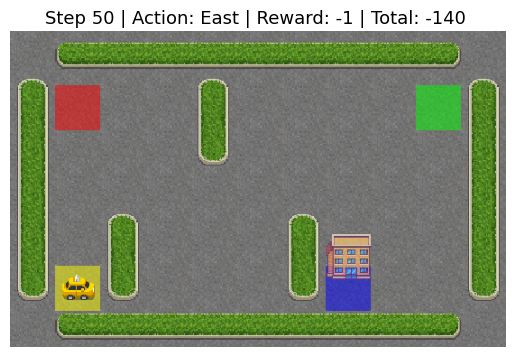


Episode finished in 50 steps with total reward -140


In [15]:
def play_taxi_mcts(env_P, n_actions, n_iterations=200, max_steps=50, delay=0.4):
    """Play one Taxi-v3 episode using MCTS, rendering each step as RGB frames."""
    env_render = gym.make("Taxi-v3", render_mode="rgb_array")
    state, _ = env_render.reset()

    clear_output(wait=True)
    plt.imshow(env_render.render())
    plt.axis("off")
    plt.title("Step 0 | Start", fontsize=13)
    plt.show()
    time.sleep(delay)

    total_reward = 0
    for step in range(1, max_steps + 1):
        action, _ = mcts_search(state, env_P, n_actions, n_iterations=n_iterations)
        next_state, reward, terminated, truncated, _ = env_render.step(action)
        done = terminated or truncated
        total_reward += reward

        clear_output(wait=True)
        plt.imshow(env_render.render())
        plt.axis("off")
        status = "SUCCESS!" if (terminated and reward >= 20) else ""
        plt.title(
            f"Step {step} | Action: {action_names[action]} | Reward: {reward} | Total: {total_reward} {status}",
            fontsize=13,
            color="green" if status == "SUCCESS!" else "black",
        )
        plt.show()

        if done:
            break
        state = next_state
        time.sleep(delay)

    env_render.close()
    print(f"\nEpisode finished in {step} steps with total reward {total_reward}")


play_taxi_mcts(env_P, n_actions, n_iterations=200)